In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import UpROOT.io as io
import UpROOT.config as cf
import UpROOT.physics.b2hhh as ph
import UpROOT.fitting.b2hhh as ft
import UpROOT.plotting.b2hhh as pt
import UpROOT.pipelines.b2hhh as pl

In [3]:
io.list_dataset_trees(
    dataset="b2hhh"
)


Archivo: B2HHH_MagnetUp.root
Árboles encontrados (1):
1. DecayTree

Archivo: B2HHH_MagnetDown.root
Árboles encontrados (1):
1. DecayTree


{WindowsPath('C:/Users/mario/Documents/PF/data/B2HHH_MagnetUp.root'): ['DecayTree'],
 WindowsPath('C:/Users/mario/Documents/PF/data/B2HHH_MagnetDown.root'): ['DecayTree']}

In [4]:
io.list_branches(
    dataset='b2hhh',
    show_trees=True,
    show_branches=True,
    txt_path="b2hhh",
)

Árboles encontrados (1):
1. DecayTree
Archivo: B2HHH_MagnetUp.root
Árbol seleccionado: DecayTree
Ramas encontradas: 26
 - B_FlightDistance
 - B_VertexChi2
 - H1_Charge
 - H1_IPChi2
 - H1_PX
 - H1_PY
 - H1_PZ
 - H1_ProbK
 - H1_ProbPi
 - H1_isMuon
 - H2_Charge
 - H2_IPChi2
 - H2_PX
 - H2_PY
 - H2_PZ
 - H2_ProbK
 - H2_ProbPi
 - H2_isMuon
 - H3_Charge
 - H3_IPChi2
 - H3_PX
 - H3_PY
 - H3_PZ
 - H3_ProbK
 - H3_ProbPi
 - H3_isMuon
Lista de ramas guardada en: C:\Users\mario\Documents\PF\MadGraph\assset\txt\branches\b2hhh.txt


['B_FlightDistance',
 'B_VertexChi2',
 'H1_Charge',
 'H1_IPChi2',
 'H1_PX',
 'H1_PY',
 'H1_PZ',
 'H1_ProbK',
 'H1_ProbPi',
 'H1_isMuon',
 'H2_Charge',
 'H2_IPChi2',
 'H2_PX',
 'H2_PY',
 'H2_PZ',
 'H2_ProbK',
 'H2_ProbPi',
 'H2_isMuon',
 'H3_Charge',
 'H3_IPChi2',
 'H3_PX',
 'H3_PY',
 'H3_PZ',
 'H3_ProbK',
 'H3_ProbPi',
 'H3_isMuon']

In [5]:
df = io.load_dataframe(
    branches=None,
    dataset='b2hhh'
)
df.head()

Archivo: B2HHH_MagnetUp.root
Árbol seleccionado: DecayTree
Archivo: B2HHH_MagnetDown.root
Árbol seleccionado: DecayTree
Total de eventos: 8,556,118 eventos


,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
0,11.241923,3.870827,1038.634354,4933.332660,164858.932313,0.012529,0.022087,1,16.937403,0,...,10.985674,0,-1946.910223,39.196412,29045.997481,0.009646,0.893131,-1,492.019550,0
1,14.429881,10.294972,-318.157696,-6407.683029,152900.152771,0.066721,0.685733,1,21.398055,0,...,351.338309,0,-1151.694873,-2406.638825,33660.348215,0.946793,0.068788,-1,587.399033,0
2,12.489381,9.303937,-97.802248,199.043666,4381.611081,0.063709,0.867898,1,1.154180,0,...,828.728775,0,627.983171,6277.041303,163852.187436,0.096775,0.534711,-1,3.511918,0
3,9.420983,4.829225,-527.819868,-651.630894,5063.986480,0.006649,0.995989,-1,1559.846172,0,...,3.262061,0,-2269.719699,-3665.766947,107937.151828,0.073778,0.096622,1,6.836508,1
4,7.362626,5.922298,-61.928986,552.828398,27007.961659,0.004962,0.211233,-1,8.178476,0,...,495.128111,0,-3236.872273,-94.994283,145404.605206,0.138766,0.709732,1,2.682517,0


In [6]:
io.load_dataframe(
    branches=io.txt_data("b2hhh"),
    dataset='b2hhh'
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\b2hhh.txt
Cantidad de ramas: 21
Archivo: B2HHH_MagnetUp.root
Árbol seleccionado: DecayTree
Archivo: B2HHH_MagnetDown.root
Árbol seleccionado: DecayTree
Total de eventos: 8,556,118 eventos


,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_isMuon,H2_PX,H2_PY,H2_PZ,...,H2_ProbPi,H2_Charge,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_isMuon
0,1038.634354,4933.332660,164858.932313,0.012529,0.022087,1,0,248.779834,248.630719,16906.431769,...,0.878307,-1,0,-1946.910223,39.196412,29045.997481,0.009646,0.893131,-1,0
1,-318.157696,-6407.683029,152900.152771,0.066721,0.685733,1,0,382.380373,114.052010,6374.152504,...,0.906743,-1,0,-1151.694873,-2406.638825,33660.348215,0.946793,0.068788,-1,0
2,-97.802248,199.043666,4381.611081,0.063709,0.867898,1,0,208.034060,462.606163,3814.362281,...,0.970704,-1,0,627.983171,6277.041303,163852.187436,0.096775,0.534711,-1,0
3,-527.819868,-651.630894,5063.986480,0.006649,0.995989,-1,0,80.115036,-68.143638,2111.592278,...,0.772366,1,0,-2269.719699,-3665.766947,107937.151828,0.073778,0.096622,1,1
4,-61.928986,552.828398,27007.961659,0.004962,0.211233,-1,0,-787.337582,-1503.071145,15912.287168,...,0.455540,1,0,-3236.872273,-94.994283,145404.605206,0.138766,0.709732,1,0


In [7]:
p_KKK = (
    '(H1_ProbK > 0.5) & (H2_ProbK > 0.5) & (H3_ProbK > 0.5) & '
    '(H1_ProbPi < 0.5) & (H2_ProbPi < 0.5) & (H3_ProbPi < 0.5) & '
    '(H1_isMuon == 0) & (H2_isMuon == 0) & (H3_isMuon == 0)'
)
m_KKK = (cf.mK, cf.mK, cf.mK)
cn_KKK = 'B±→K±K+K-'
safe_KKK = 'Bpm_to_KKK'
models = (
    'gauss_exp',
    'gauss_cheb',
    'cb_linear',
    'gauss_linear_sigmoid'
)
df_KKK = io.load_dataframe(
    branches=None,
    cut=p_KKK,
    dataset='b2hhh'
)
df_KKK.head()

Archivo: B2HHH_MagnetUp.root
Árbol seleccionado: DecayTree
Archivo: B2HHH_MagnetDown.root
Árbol seleccionado: DecayTree
Total de eventos: 23,895 eventos


,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
325,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,...,714.174519,0,-8864.962492,-7428.640292,77446.175923,0.934580,0.128720,1,536.585115,0
539,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,...,737.219732,0,-341.750434,3317.423370,24380.200353,0.968883,0.129317,1,23332.453390,0
588,16.531858,11.593388,1493.048615,1944.600925,33003.915368,0.953512,0.104768,-1,1731.923563,0,...,499.998835,0,4779.029220,-287.829864,53908.496894,0.844950,0.064803,1,3484.193030,0
1086,4.102797,11.321708,-236.694032,843.809179,28207.109021,0.655129,0.045339,-1,5.033764,0,...,6.588705,0,-1085.332141,-3076.759324,30036.196827,0.912293,0.080841,1,489.046805,0
1236,3.509346,5.739399,123.873807,856.290459,51956.566616,0.940484,0.078221,-1,7.005894,0,...,2.090424,0,1639.997962,2660.275891,19441.349314,0.702135,0.028641,1,888.535134,0


In [8]:
df_KKK = ph.calc_B_mass(df_KKK, m_KKK)
df_KKK.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,H2_P,H2_E,H3_P,H3_E,B_E,B_PX,B_PY,B_PZ,B_M,B_Charge
325,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,...,19666.70,19672.895208,78305.06,78306.616187,122894.472851,-16426.654124,-8840.468720,121353.729945,5323.047342,1
539,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,...,17718.46,17725.336153,24607.24,24612.191642,77934.211270,1567.644685,3719.483808,77651.562792,5261.559902,1
588,16.531858,11.593388,1493.048615,1944.600925,33003.915368,0.953512,0.104768,-1,1731.923563,0,...,30076.24,30080.291380,54120.68,54122.931560,117301.754834,6645.691830,2500.385609,116974.497013,5123.630303,1
1086,4.102797,11.321708,-236.694032,843.809179,28207.109021,0.655129,0.045339,-1,5.033764,0,...,30105.87,30109.917393,30212.87,30216.903061,88551.858175,-1883.932031,-2422.302813,88343.336012,5241.165686,1
1236,3.509346,5.739399,123.873807,856.290459,51956.566616,0.940484,0.078221,-1,7.005894,0,...,24997.41,25002.284369,19690.93,19697.117587,96665.516970,1874.625156,4587.542215,96372.127651,5663.516584,1


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\momentum_Bpm_to_KKK.png.


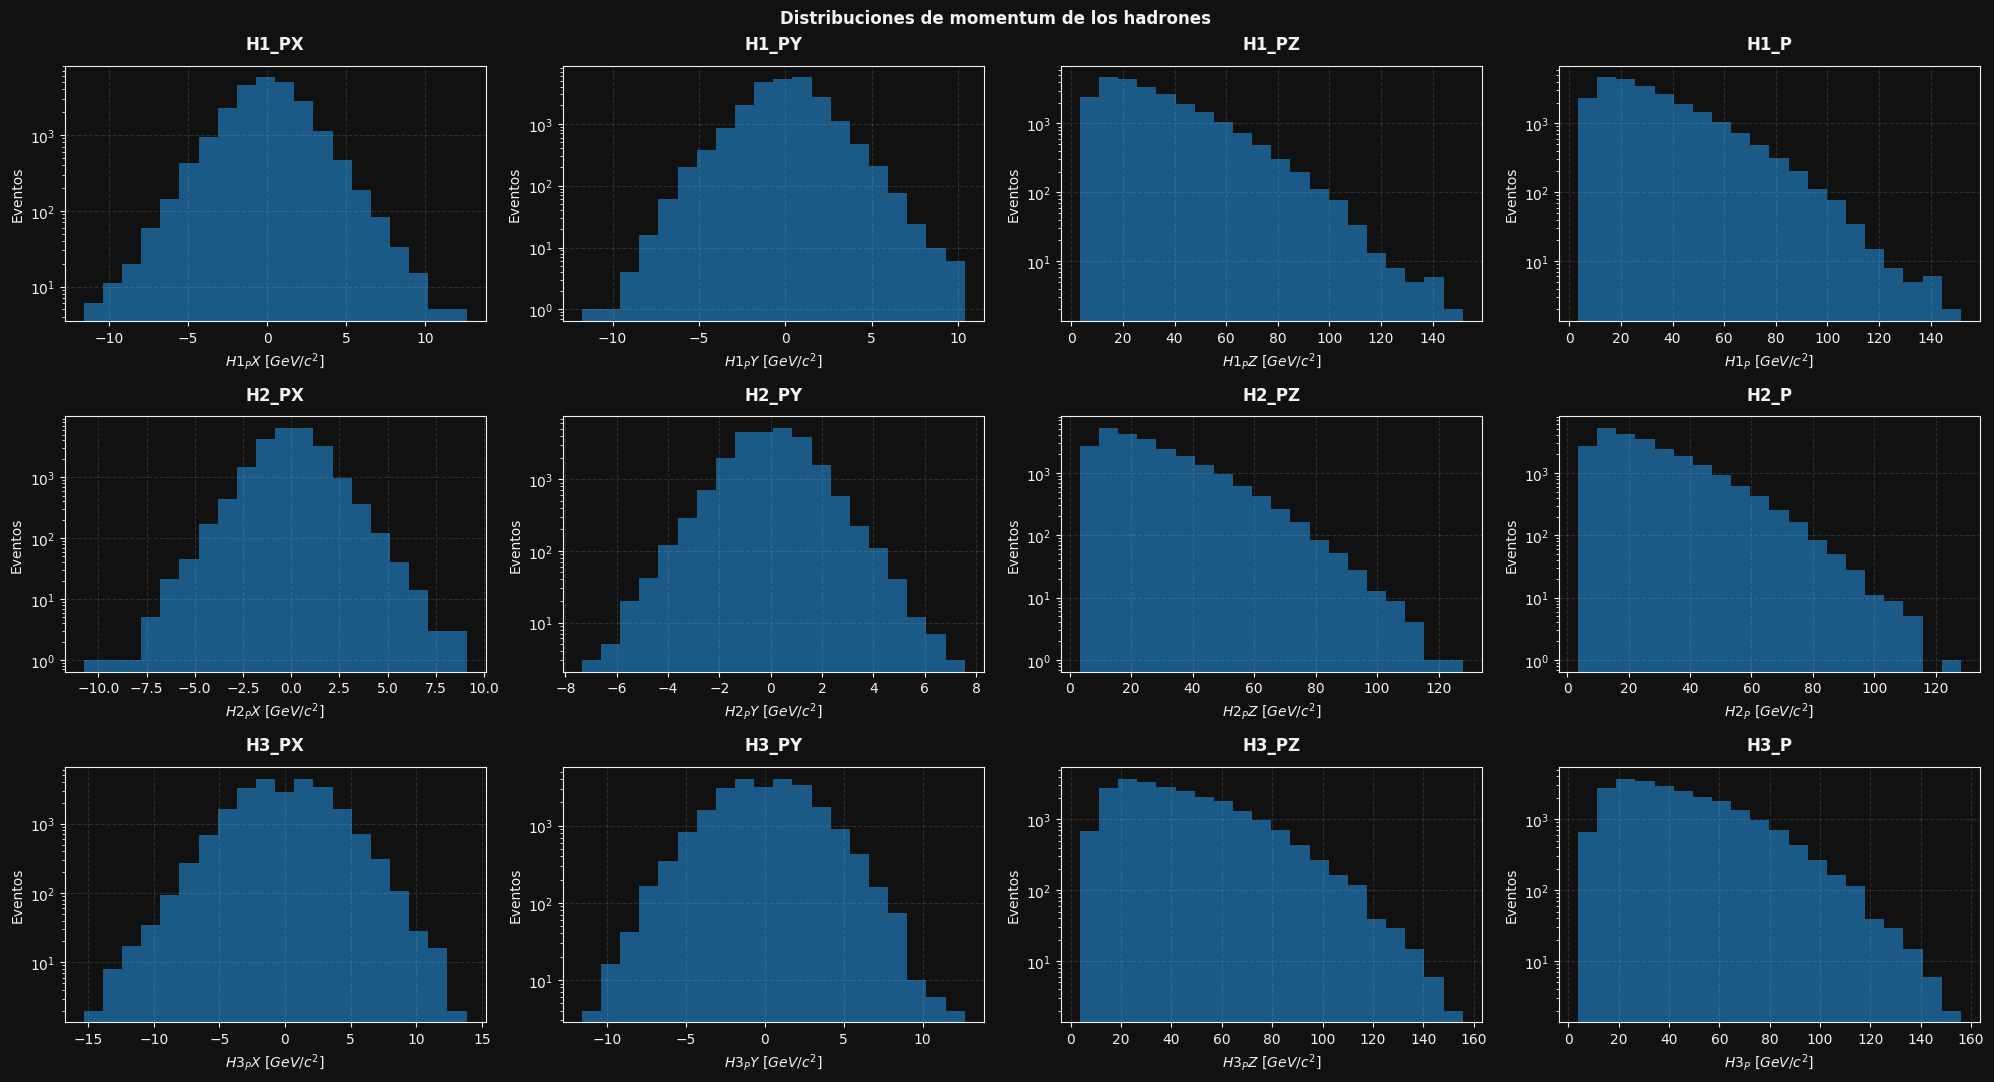

(<Figure size 2000x1100 with 12 Axes>,
 array([[<Axes: title={'center': 'H1_PX'}, xlabel='$H1_PX$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H1_PY'}, xlabel='$H1_PY$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H1_PZ'}, xlabel='$H1_PZ$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H1_P'}, xlabel='$H1_P$ [$GeV/c^2$]', ylabel='Eventos'>],
        [<Axes: title={'center': 'H2_PX'}, xlabel='$H2_PX$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H2_PY'}, xlabel='$H2_PY$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H2_PZ'}, xlabel='$H2_PZ$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H2_P'}, xlabel='$H2_P$ [$GeV/c^2$]', ylabel='Eventos'>],
        [<Axes: title={'center': 'H3_PX'}, xlabel='$H3_PX$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H3_PY'}, xlabel='$H3_PY$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'H3_PZ'}, 

In [9]:
pt.plot_momentum(
    df=df_KKK,
    bins=20,
    save=True,
    filename=f"momentum_{safe_KKK}",
    data='data'
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\energy_Bpm_to_KKK.png.


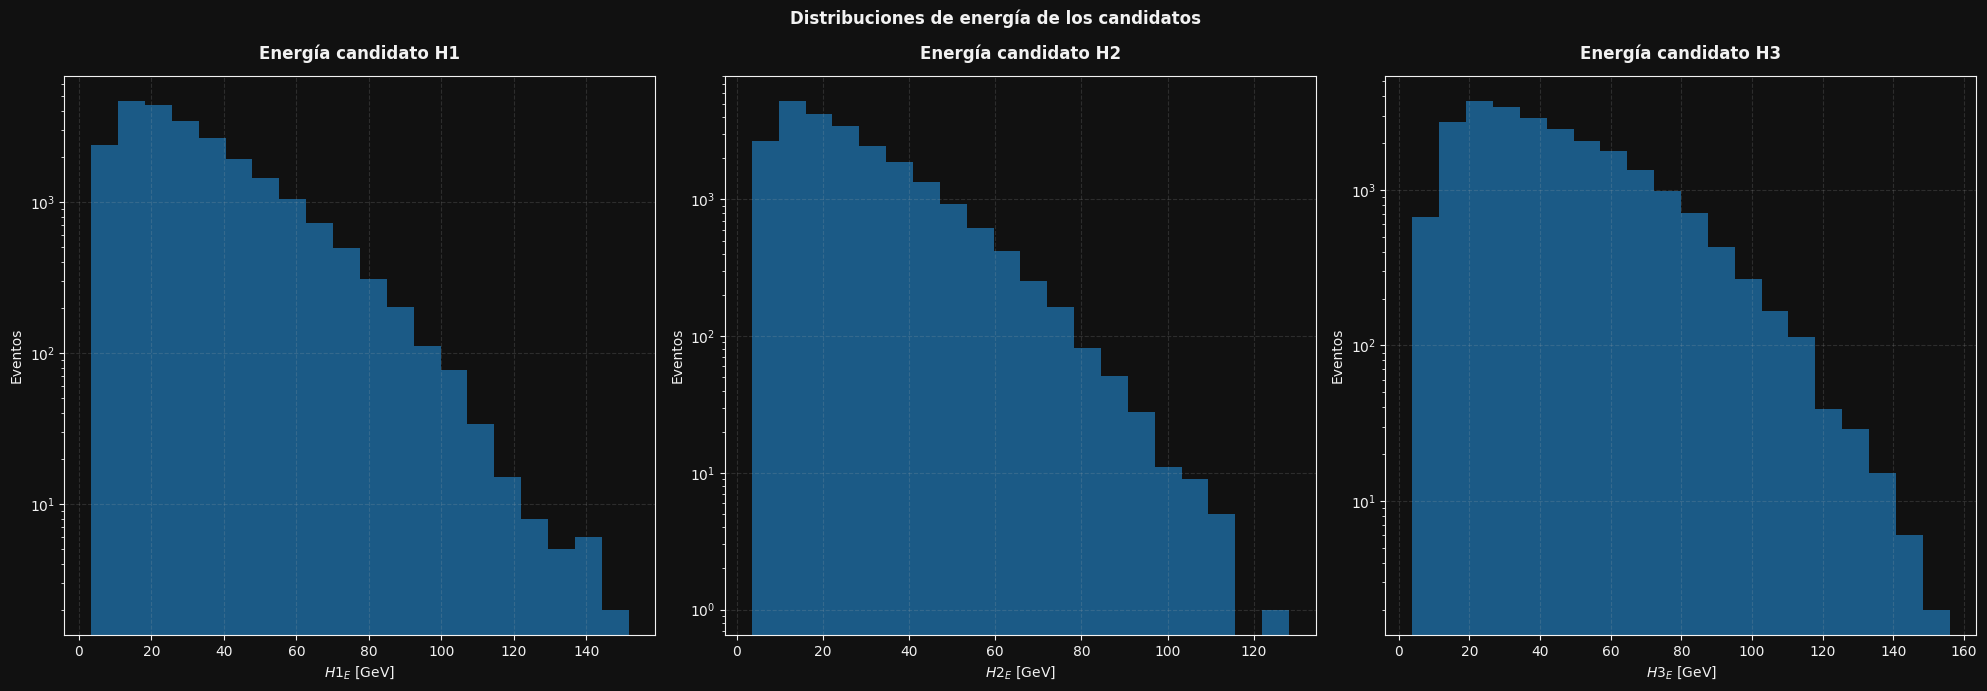

(<Figure size 2000x700 with 3 Axes>,
 array([[<Axes: title={'center': 'Energía candidato H1'}, xlabel='$H1_E$ [GeV]', ylabel='Eventos'>,
         <Axes: title={'center': 'Energía candidato H2'}, xlabel='$H2_E$ [GeV]', ylabel='Eventos'>,
         <Axes: title={'center': 'Energía candidato H3'}, xlabel='$H3_E$ [GeV]', ylabel='Eventos'>]],
       dtype=object))

In [10]:
pt.plot_energy(
    df_KKK,
    bins=20,
    save=True,
    log_y=True,
    filename=f'energy_{safe_KKK}',
    data='data',
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\mass_Bpm_to_KKK.png.


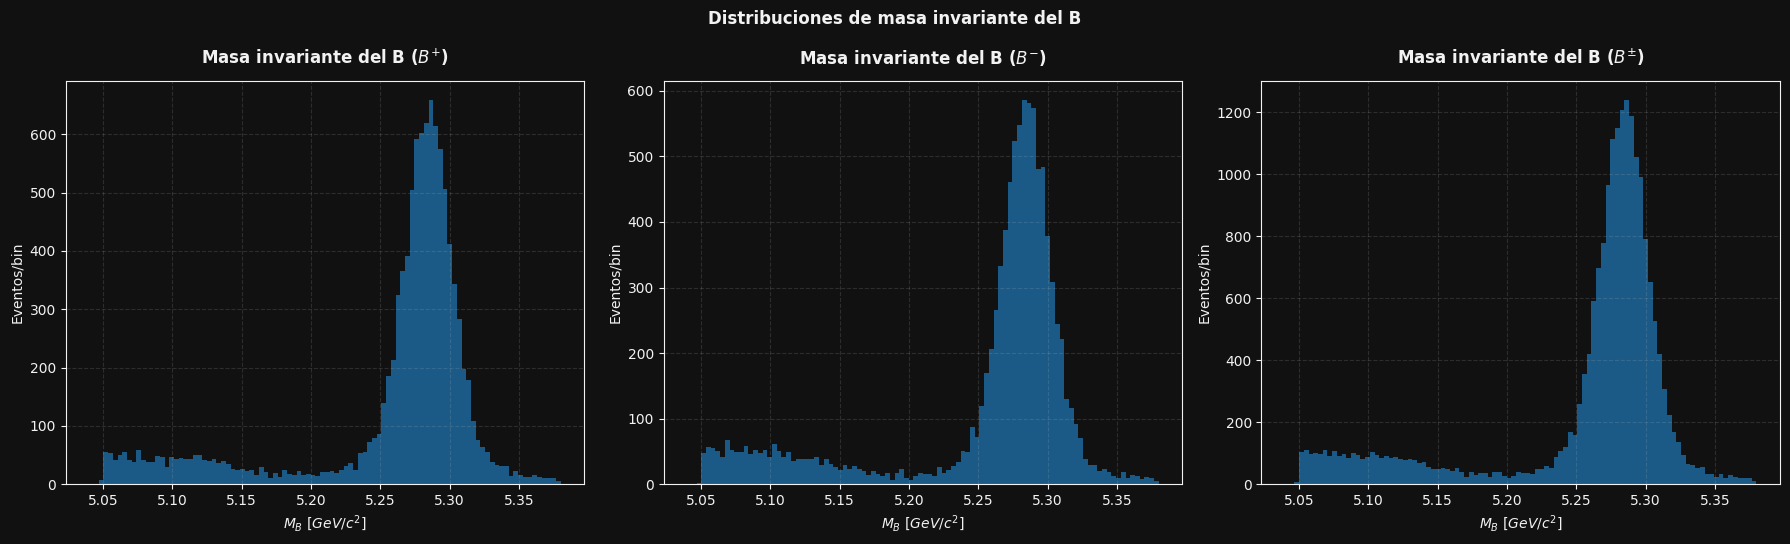

(<Figure size 1800x550 with 3 Axes>,
 array([[<Axes: title={'center': 'Masa invariante del B ($B^{+}$)'}, xlabel='$M_{B}$ [$GeV/c^{2}$]', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'Masa invariante del B ($B^{-}$)'}, xlabel='$M_{B}$ [$GeV/c^{2}$]', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'Masa invariante del B ($B^{\\pm}$)'}, xlabel='$M_{B}$ [$GeV/c^{2}$]', ylabel='Eventos/bin'>]],
       dtype=object))

In [11]:
pt.plot_mass(
    df_KKK,
    bins=100,
    mass_range=(5.040, 5.380),
    save=True,
    filename=f'mass_{safe_KKK}',
    data='data',
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\prob_particle_Bpm_to_KKK.png.


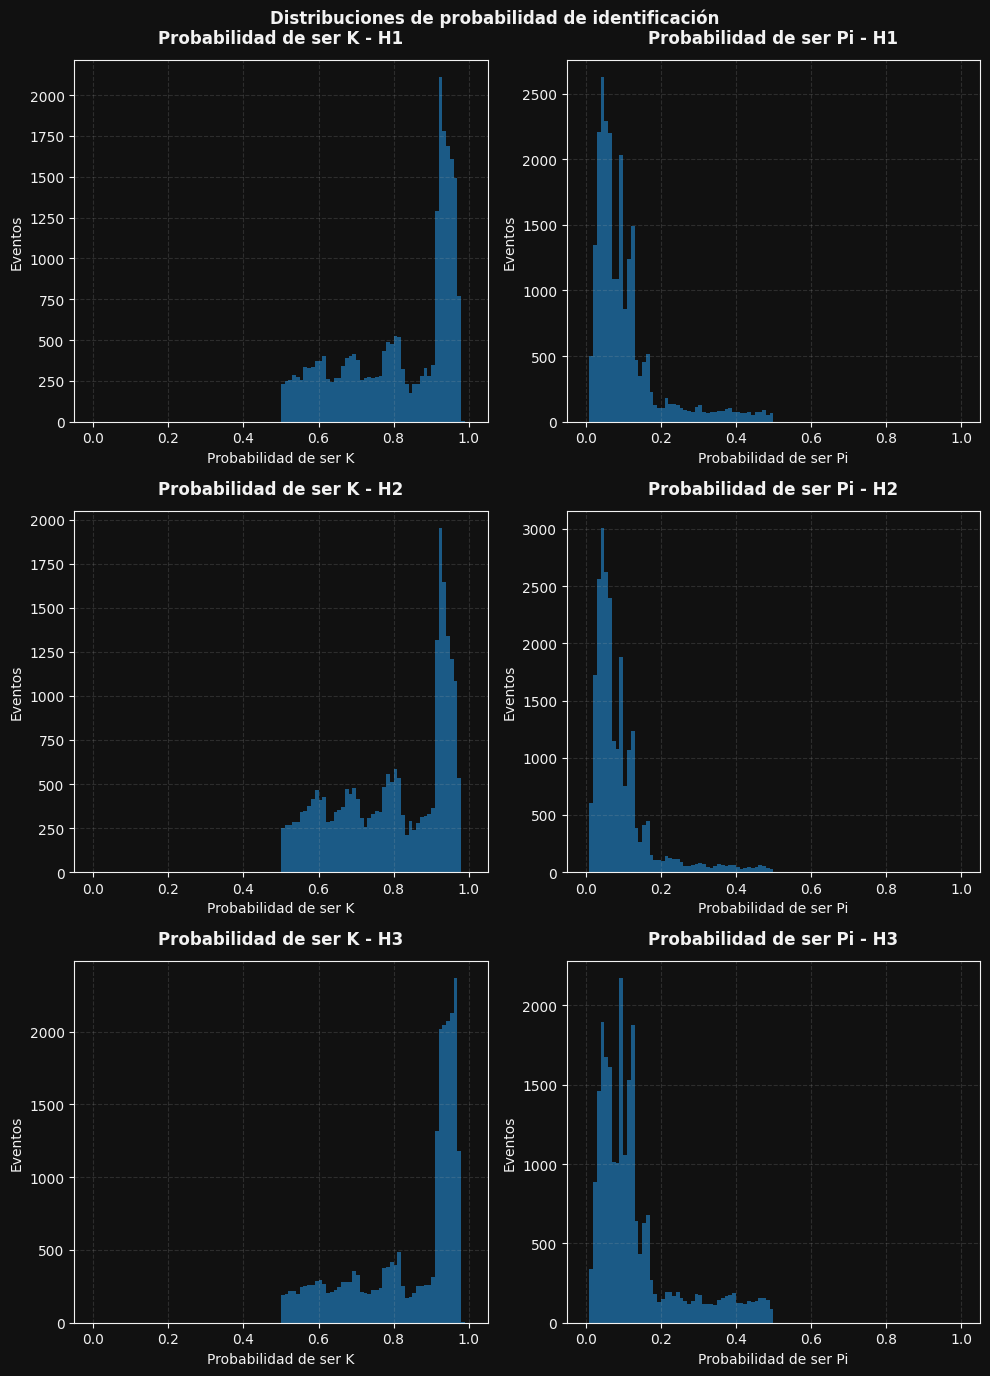

(<Figure size 1000x1400 with 6 Axes>,
 array([[<Axes: title={'center': 'Probabilidad de ser K - H1'}, xlabel='Probabilidad de ser K', ylabel='Eventos'>,
         <Axes: title={'center': 'Probabilidad de ser Pi - H1'}, xlabel='Probabilidad de ser Pi', ylabel='Eventos'>],
        [<Axes: title={'center': 'Probabilidad de ser K - H2'}, xlabel='Probabilidad de ser K', ylabel='Eventos'>,
         <Axes: title={'center': 'Probabilidad de ser Pi - H2'}, xlabel='Probabilidad de ser Pi', ylabel='Eventos'>],
        [<Axes: title={'center': 'Probabilidad de ser K - H3'}, xlabel='Probabilidad de ser K', ylabel='Eventos'>,
         <Axes: title={'center': 'Probabilidad de ser Pi - H3'}, xlabel='Probabilidad de ser Pi', ylabel='Eventos'>]],
       dtype=object))

In [12]:
pt.plot_prob_particle(
    df_KKK,
    bins=100,
    save=True,
    filename=f'prob_particle_{safe_KKK}',
    data='data',
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\prob2d_Bpm_to_KKK.png.


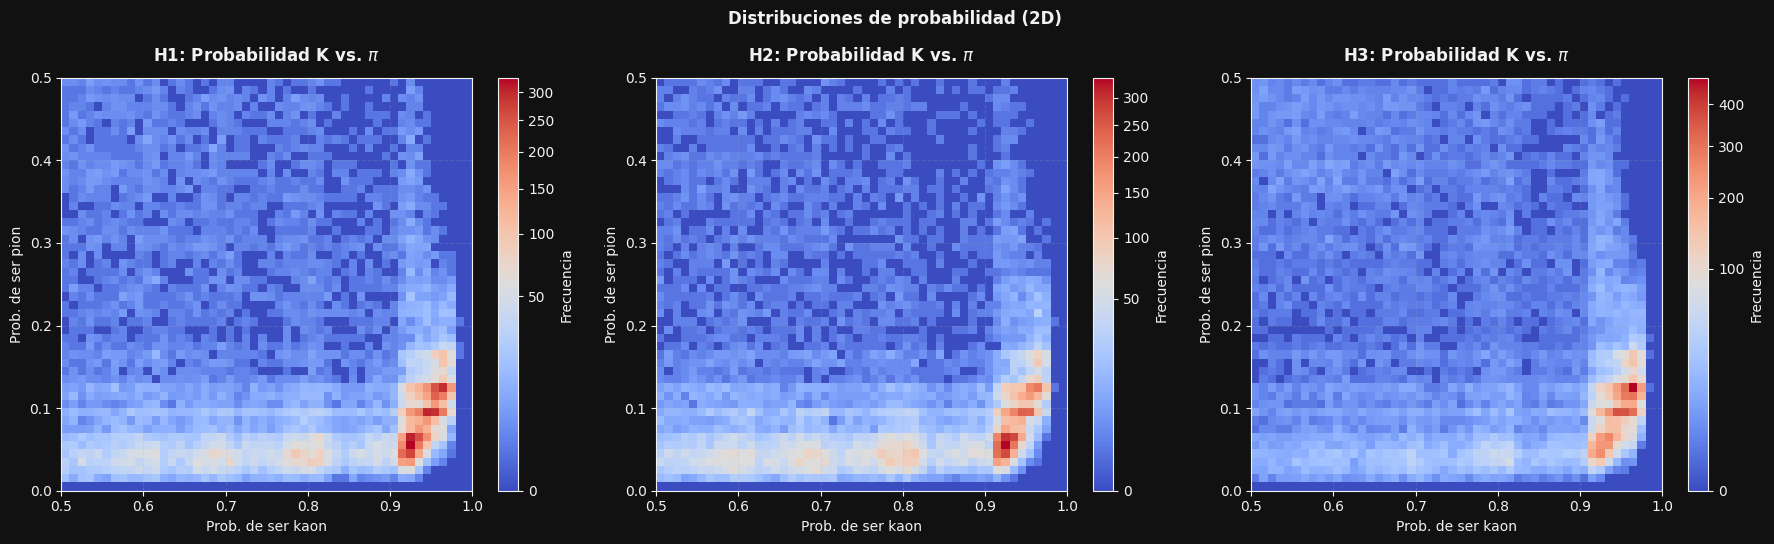

(<Figure size 1800x550 with 6 Axes>,
 array([[<Axes: title={'center': 'H1: Probabilidad K vs. $\\pi$'}, xlabel='Prob. de ser kaon', ylabel='Prob. de ser pion'>,
         <Axes: title={'center': 'H2: Probabilidad K vs. $\\pi$'}, xlabel='Prob. de ser kaon', ylabel='Prob. de ser pion'>,
         <Axes: title={'center': 'H3: Probabilidad K vs. $\\pi$'}, xlabel='Prob. de ser kaon', ylabel='Prob. de ser pion'>]],
       dtype=object))

In [13]:
pt.plot_probability_distributions(
    df_KKK,
    bins=50,
    save=True,
    filename=f'prob2d_{safe_KKK}',
    data='data',
)

In [14]:
Np = int((df_KKK['B_Charge'] == 1).sum())
Nm = int((df_KKK['B_Charge'] == -1).sum())
acp_KKK = ph.compute_acp(Np, Nm)
print(f"Np: {acp_KKK['N_positive']}    Nm: {acp_KKK['N_negative']}")
print(f"A_CP = {acp_KKK['A']:+.4f} ± {acp_KKK['sigma']:.4f}   (significancia = {acp_KKK['significance']:+.2f} σ)")

Np: 12390    Nm: 11505
A_CP = -0.0370 ± 0.0065   (significancia = -5.73 σ)


In [15]:
df_KKK = ph.calc_dalitz_vars(df_KKK)
df_KKK.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,B_E,B_PX,B_PY,B_PZ,B_M,B_Charge,m2_12,m2_13,R0low,R0high
325,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,...,122894.472851,-16426.654124,-8840.468720,121353.729945,5323.047342,1,1.031222e+06,1.571088e+07,1.031222e+06,1.571088e+07
539,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,...,77934.211270,1567.644685,3719.483808,77651.562792,5261.559902,1,1.592279e+06,1.962077e+07,1.592279e+06,1.962077e+07
588,16.531858,11.593388,1493.048615,1944.600925,33003.915368,0.953512,0.104768,-1,1731.923563,0,...,117301.754834,6645.691830,2500.385609,116974.497013,5123.630303,1,2.984764e+06,1.173243e+07,2.984764e+06,1.173243e+07
1086,4.102797,11.321708,-236.694032,843.809179,28207.109021,0.655129,0.045339,-1,5.033764,0,...,88551.858175,-1883.932031,-2422.302813,88343.336012,5241.165686,1,2.178433e+06,1.644395e+07,2.178433e+06,1.644395e+07
1236,3.509346,5.739399,123.873807,856.290459,51956.566616,0.940484,0.078221,-1,7.005894,0,...,96665.516970,1874.625156,4587.542215,96372.127651,5663.516584,1,2.020443e+06,2.247903e+07,2.020443e+06,2.247903e+07


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\msquare_Bpm_to_KKK.png.


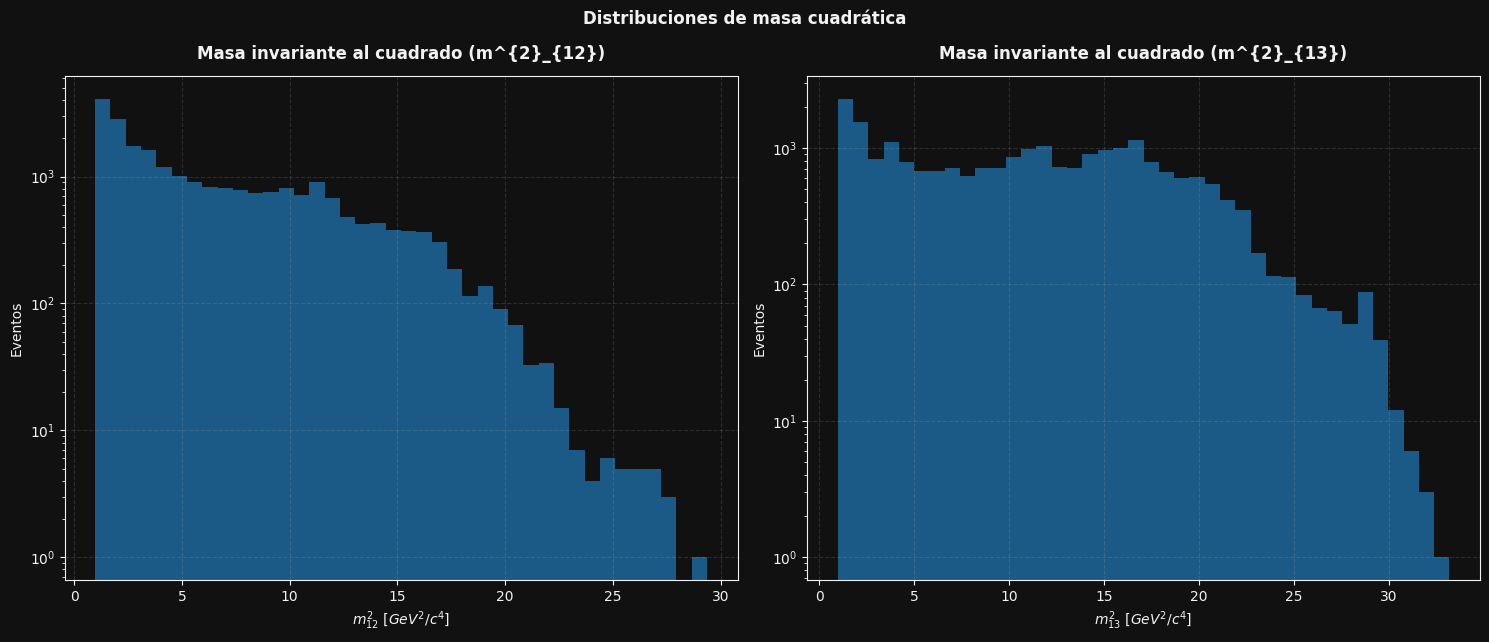

(<Figure size 1500x650 with 2 Axes>,
 array([[<Axes: title={'center': 'Masa invariante al cuadrado (m^{2}_{12})'}, xlabel='$m^{2}_{12}$ [$GeV^2/c^4$]', ylabel='Eventos'>,
         <Axes: title={'center': 'Masa invariante al cuadrado (m^{2}_{13})'}, xlabel='$m^{2}_{13}$ [$GeV^2/c^4$]', ylabel='Eventos'>]],
       dtype=object))

In [16]:
pt.plot_square_mass_dist(
    df_KKK,
    bins=40,
    save=True,
    filename=f'msquare_{safe_KKK}',
    data='data',
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\binned_dalitz_Bpm_to_KKK.png.


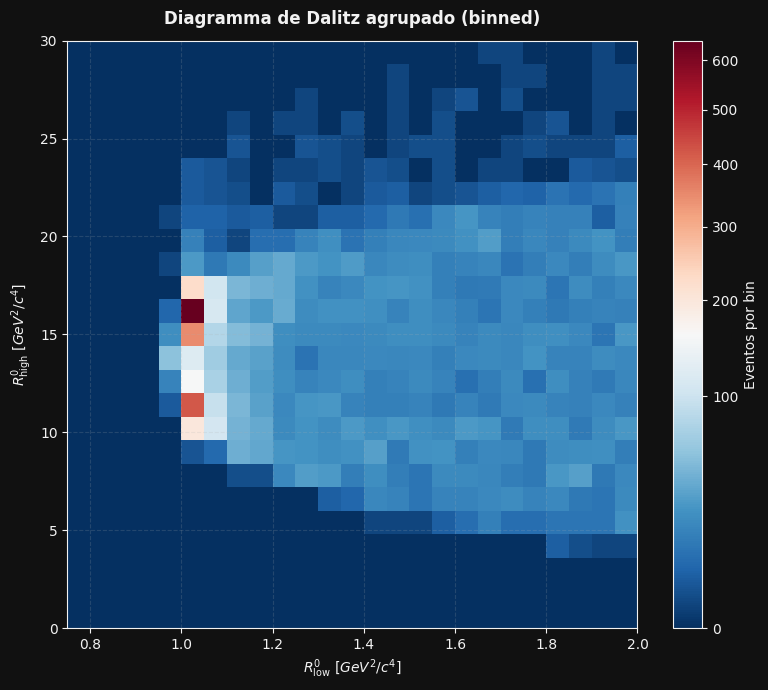

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Diagramma de Dalitz agrupado (binned)'}, xlabel='$R^{0}_{\\mathrm{low}}$ [$GeV^2/c^4$]', ylabel='$R^{0}_{\\mathrm{high}}$ [$GeV^2/c^4$]'>)

In [17]:
pt.plot_binned_dalitz(
    df_KKK,
    bins=25,
    save=True,
    filename=f'binned_dalitz_{safe_KKK}',
    data='data',
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\projection_mass_Bpm_to_KKK.png.


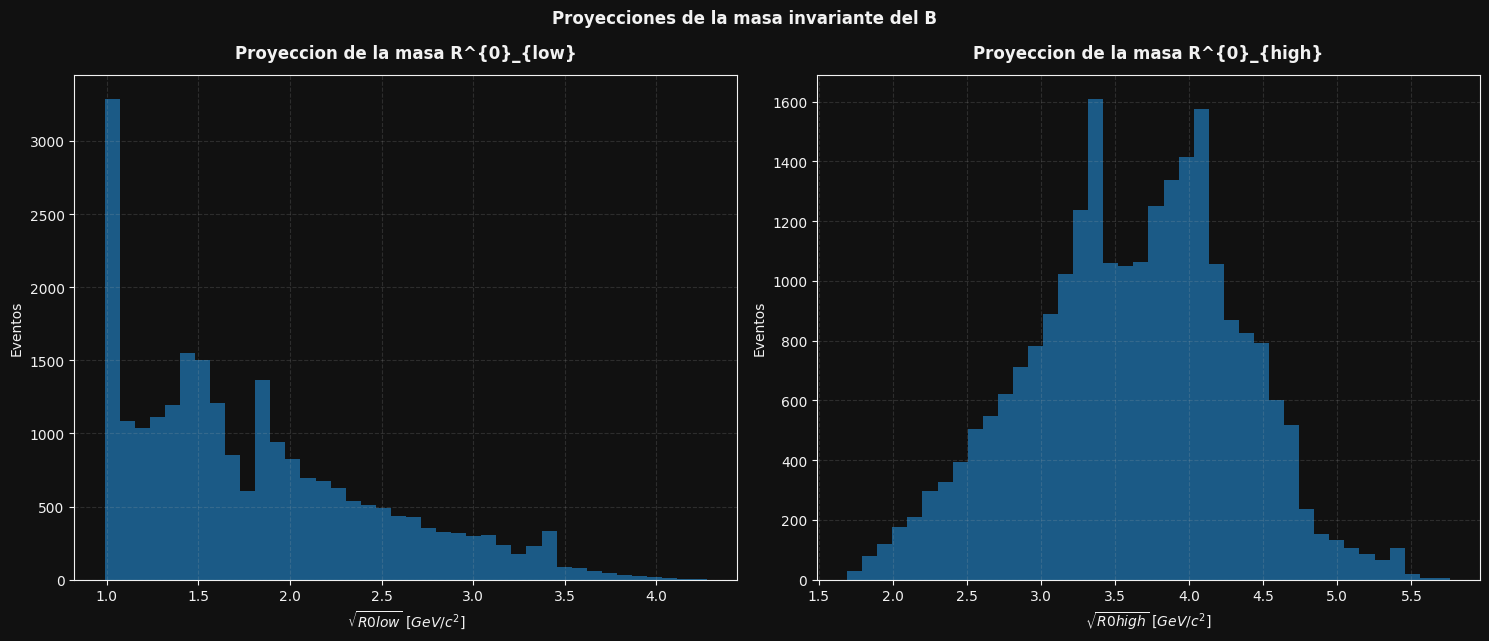

(<Figure size 1500x650 with 2 Axes>,
 array([[<Axes: title={'center': 'Proyeccion de la masa R^{0}_{low}'}, xlabel='$\\sqrt{R0low}$ [$GeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'Proyeccion de la masa R^{0}_{high}'}, xlabel='$\\sqrt{R0high}$ [$GeV/c^2$]', ylabel='Eventos'>]],
       dtype=object))

In [18]:
pt.plot_proyection_mass(
    df_KKK,
    bins=40,
    save=True,
    filename=f'projection_mass_{safe_KKK}',
    data='data',
)

In [19]:
dalitz_KKK = ph.dalitz_data(df_KKK)
dalitz_KKK['df_sig'].head()

Tras charm veto: 15,024 eventos


,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,B_E,B_PX,B_PY,B_PZ,B_M,B_Charge,m2_12,m2_13,R0low,R0high
325,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,...,122894.472851,-16426.654124,-8840.468720,121353.729945,5323.047342,1,1.031222e+06,1.571088e+07,1.031222e+06,1.571088e+07
539,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,...,77934.211270,1567.644685,3719.483808,77651.562792,5261.559902,1,1.592279e+06,1.962077e+07,1.592279e+06,1.962077e+07
1086,4.102797,11.321708,-236.694032,843.809179,28207.109021,0.655129,0.045339,-1,5.033764,0,...,88551.858175,-1883.932031,-2422.302813,88343.336012,5241.165686,1,2.178433e+06,1.644395e+07,2.178433e+06,1.644395e+07
1849,9.065305,3.527310,2188.439032,4218.351017,29432.403877,0.638756,0.063052,1,2598.177695,0,...,83554.457347,6307.347723,6069.182655,82924.949957,5308.710168,-1,2.011988e+06,2.110348e+07,2.011988e+06,2.110348e+07
3302,21.262462,3.268471,-1826.811516,-1089.170866,8408.256847,0.547435,0.043218,1,19506.017157,0,...,73979.903847,-9263.157453,-175.977806,73209.056799,5255.770316,-1,1.111105e+07,9.372286e+06,9.372286e+06,1.111105e+07


c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\dalitz_summary_Bpm_to_KKK.png.


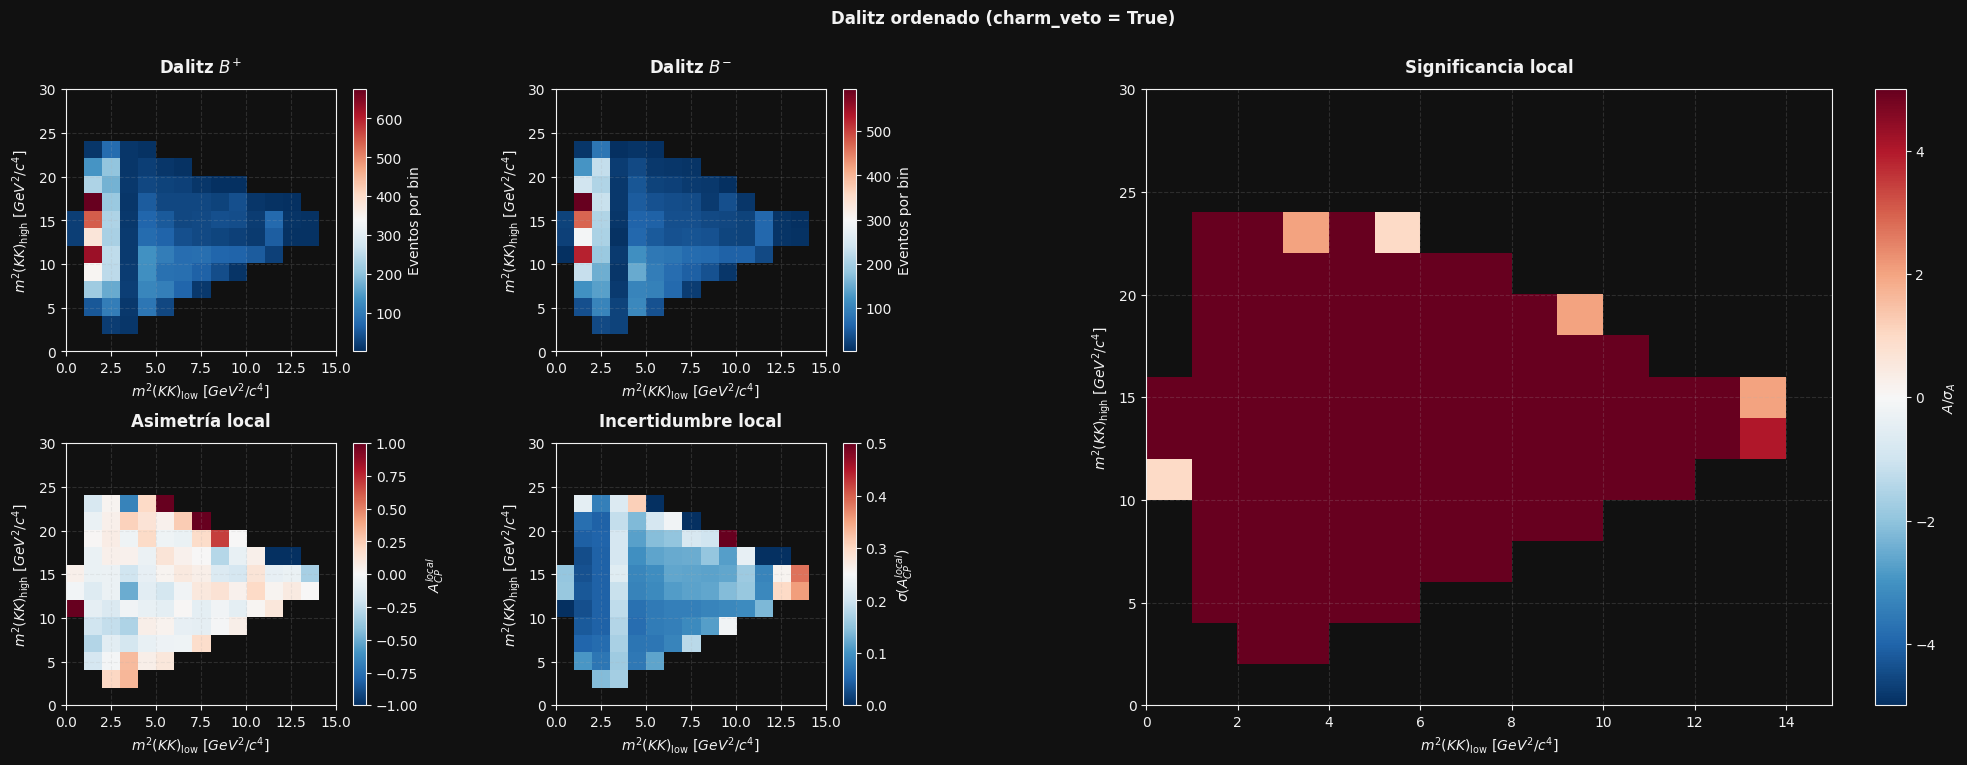

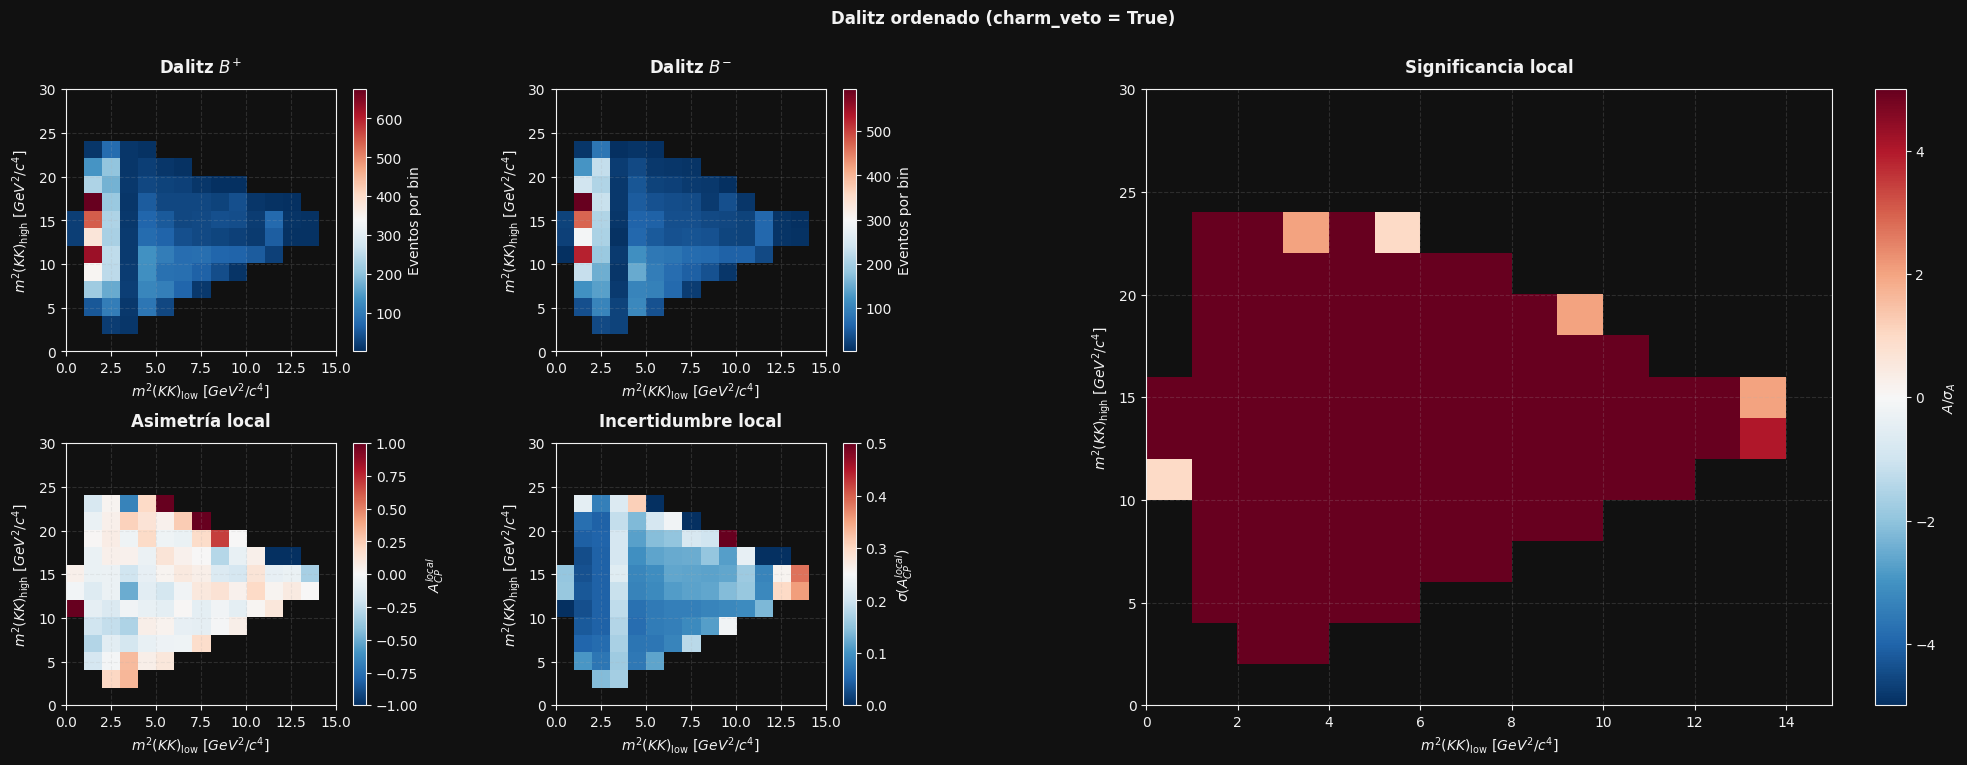

In [20]:
pt.plot_dalitz_summary(
    dalitz_KKK,
    save=True,
    filename=f'dalitz_summary_{safe_KKK}',
    data='data',
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\dalitz_scatter_Bpm_to_KKK.png.


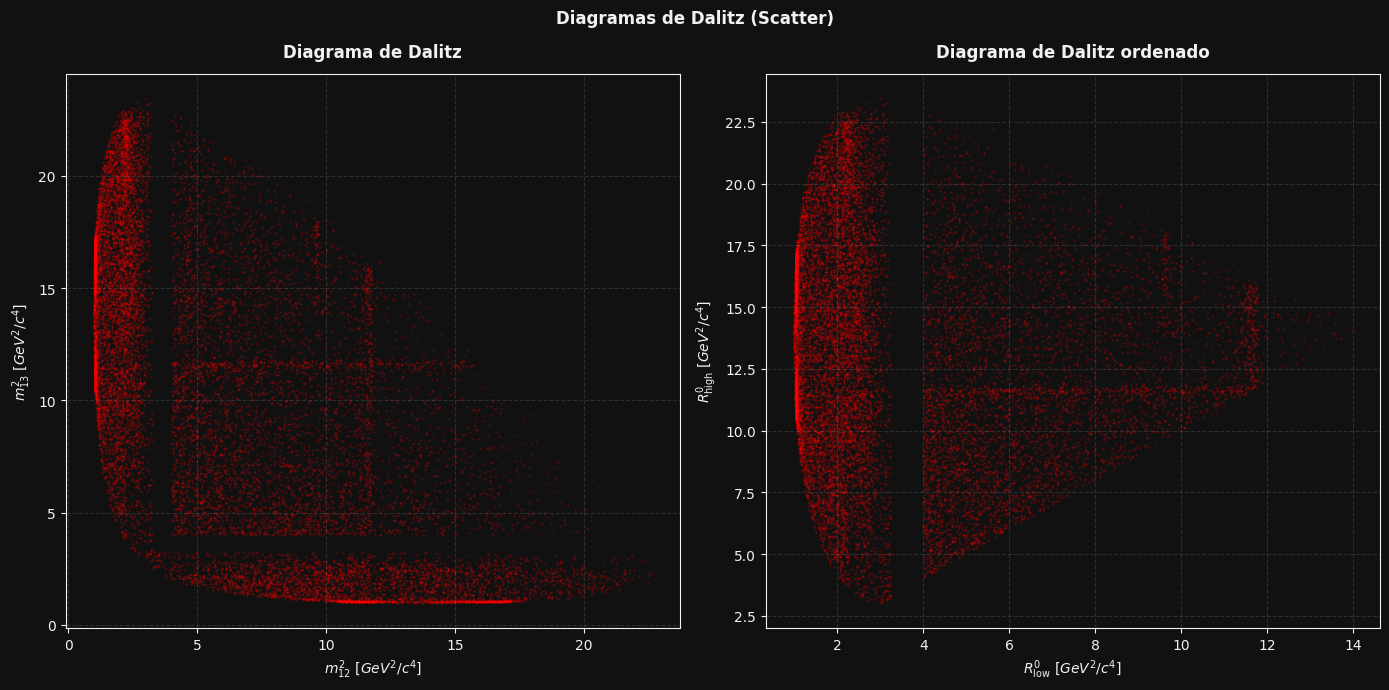

(<Figure size 1400x700 with 2 Axes>,
 array([[<Axes: title={'center': 'Diagrama de Dalitz'}, xlabel='$m^2_{12}$ [$GeV^2/c^4$]', ylabel='$m^2_{13}$ [$GeV^2/c^4$]'>,
         <Axes: title={'center': 'Diagrama de Dalitz ordenado'}, xlabel='$R^{0}_{\\mathrm{low}}$ [$GeV^2/c^4$]', ylabel='$R^{0}_{\\mathrm{high}}$ [$GeV^2/c^4$]'>]],
       dtype=object))

In [21]:
pt.plot_dalitz_scatter(
    dalitz_KKK['df_sig'],
    save=True,
    filename=f'dalitz_scatter_{safe_KKK}',
    data='data',
)

In [22]:
LCPV_KKK = ph.slarge_cpv_region(dalitz_KKK['df_sig'])
LCPV_KKK.head()

Región de gran asimetría CP: 5,861 eventos


,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,B_E,B_PX,B_PY,B_PZ,B_M,B_Charge,m2_12,m2_13,R0low,R0high
325,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,...,122894.472851,-16426.654124,-8840.468720,121353.729945,5323.047342,1,1.031222e+06,1.571088e+07,1.031222e+06,1.571088e+07
539,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,...,77934.211270,1567.644685,3719.483808,77651.562792,5261.559902,1,1.592279e+06,1.962077e+07,1.592279e+06,1.962077e+07
4691,12.749790,9.475244,631.970074,296.630342,13550.908778,0.656695,0.081665,-1,333.138068,0,...,107568.607346,3577.325004,-2111.490596,107358.141137,5289.534127,1,1.552171e+06,7.168149e+06,1.552171e+06,7.168149e+06
6044,18.776968,1.777820,383.211312,-3903.679091,21411.359864,0.950080,0.079792,-1,3672.306389,0,...,95395.600030,-1242.447416,-11365.532496,94560.741615,5278.981516,1,1.564932e+07,1.857168e+06,1.857168e+06,1.564932e+07
13358,16.500308,3.995451,-2435.429661,-1276.583665,56170.676620,0.925688,0.059150,-1,405.509798,0,...,151434.079621,-8482.476899,-6244.241471,150972.913404,5340.123871,1,1.025248e+06,1.503887e+07,1.025248e+06,1.503887e+07


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\b2hhh_large_cp_Bpm_to_KKK.png.


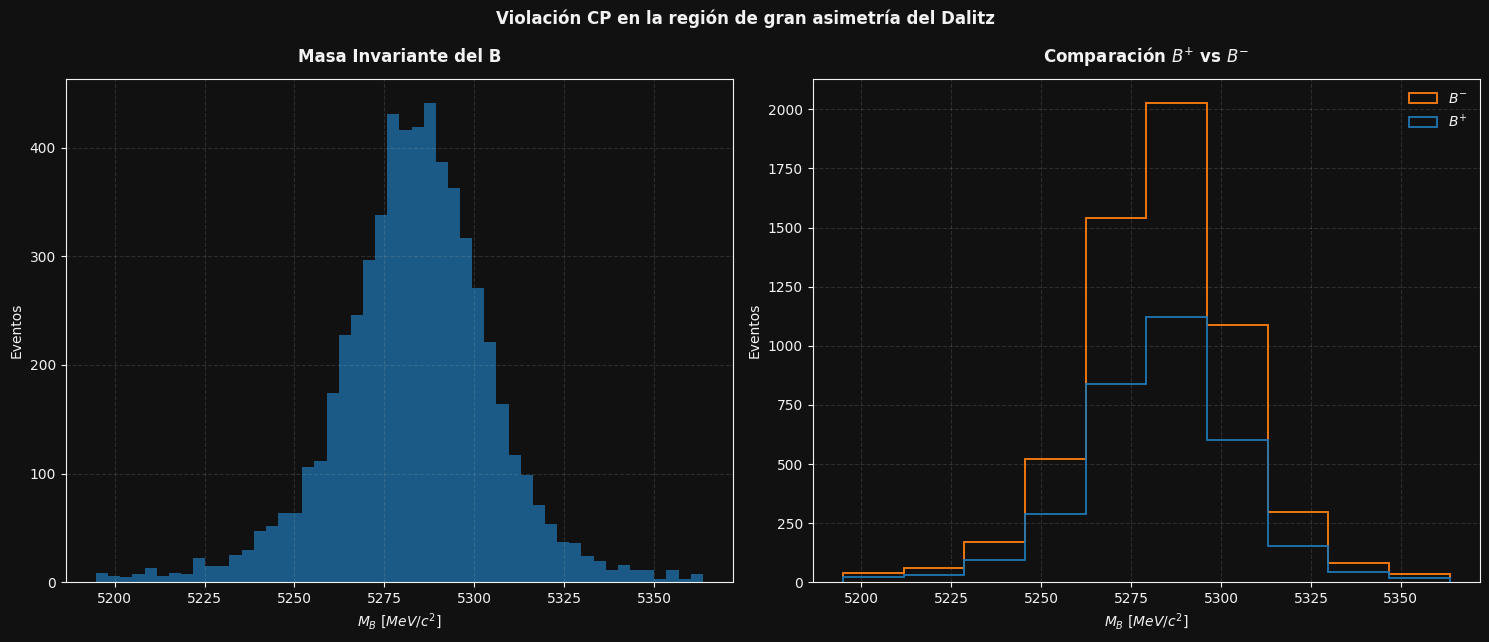

(<Figure size 1500x650 with 2 Axes>,
 array([[<Axes: title={'center': 'Masa Invariante del B'}, xlabel='$M_{B}$ [$MeV/c^2$]', ylabel='Eventos'>,
         <Axes: title={'center': 'Comparación $B^{+}$ vs $B^{-}$'}, xlabel='$M_{B}$ [$MeV/c^{2}$]', ylabel='Eventos'>]],
       dtype=object))

In [23]:
pt.plot_large_CP(
    LCPV_KKK,
    save=True,
    filename=f'b2hhh_large_cp_{safe_KKK}',
    data='data',
)

$B^{+}$ (gauss_exp): 12,390 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = gauss_exp
N_señal = 7940 ± 93
χ²/ndf  = 166.5 / 75
Media   = 5284.41 [MeV/c²]
  σ     = 17.82 [MeV/c²]
$B^{-}$ (gauss_exp): 11,505 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = gauss_exp
N_señal = 7256 ± 89
χ²/ndf  = 188.0 / 75
Media   = 5284.59 [MeV/c²]
  σ     = 17.87 [MeV/c²]
$B^{+}$ (gauss_cheb): 12,390 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = gauss_cheb
N_señal = 7979 ± 96
χ²/ndf  = 164.5 / 73
Media   = 5284.42 [MeV/c²]
  σ     = 17.92 [MeV/c²]
$B^{-}$ (gauss_cheb): 11,505 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = gauss_cheb
N_señal = 7327 ± 92
χ²/ndf  = 175.4 / 73
Media   = 5284.62 [MeV/c²]
  σ     = 18.07 [MeV/c²]
$B^{+}$ (cb_linear): 12,390 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = cb_linear
N_señal = 7936 ± 97
χ²/ndf  = 187.1 / 73
Media   = 5284.52 [MeV/c²]
  σ     = 17.49 [MeV/c²]
$B^{-}$ (cb_linear): 11,505 candidatos en [5100.0, 5500.0] $MeV/c^2$


c:\Users\mario\Documents\PF\MadGraph\UpROOT\fitting\b2hhh.py:138: RuntimeWarning: overflow encountered in power
  'upper': [2.0*N_total, 15.0, 30.0, 5320.0, 60.0, 2.0**N_total, 0.95],


Modelo  = cb_linear
N_señal = 7208 ± 89
χ²/ndf  = 225.0 / 73
Media   = 5284.55 [MeV/c²]
  σ     = 17.74 [MeV/c²]
$B^{+}$ (gauss_linear_sigmoid): 12,390 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = gauss_linear_sigmoid
N_señal = 7963 ± 141
χ²/ndf  = 105.1 / 72
Media   = 5284.32 [MeV/c²]
  σ     = 17.89 [MeV/c²]
$B^{-}$ (gauss_linear_sigmoid): 11,505 candidatos en [5100.0, 5500.0] $MeV/c^2$
Modelo  = gauss_linear_sigmoid
N_señal = 7323 ± 135
χ²/ndf  = 93.0 / 72
Media   = 5284.46 [MeV/c²]
  σ     = 18.08 [MeV/c²]
Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\b2hhh\Data\BpmtoKpmKplusKminus_mass_fit.png.


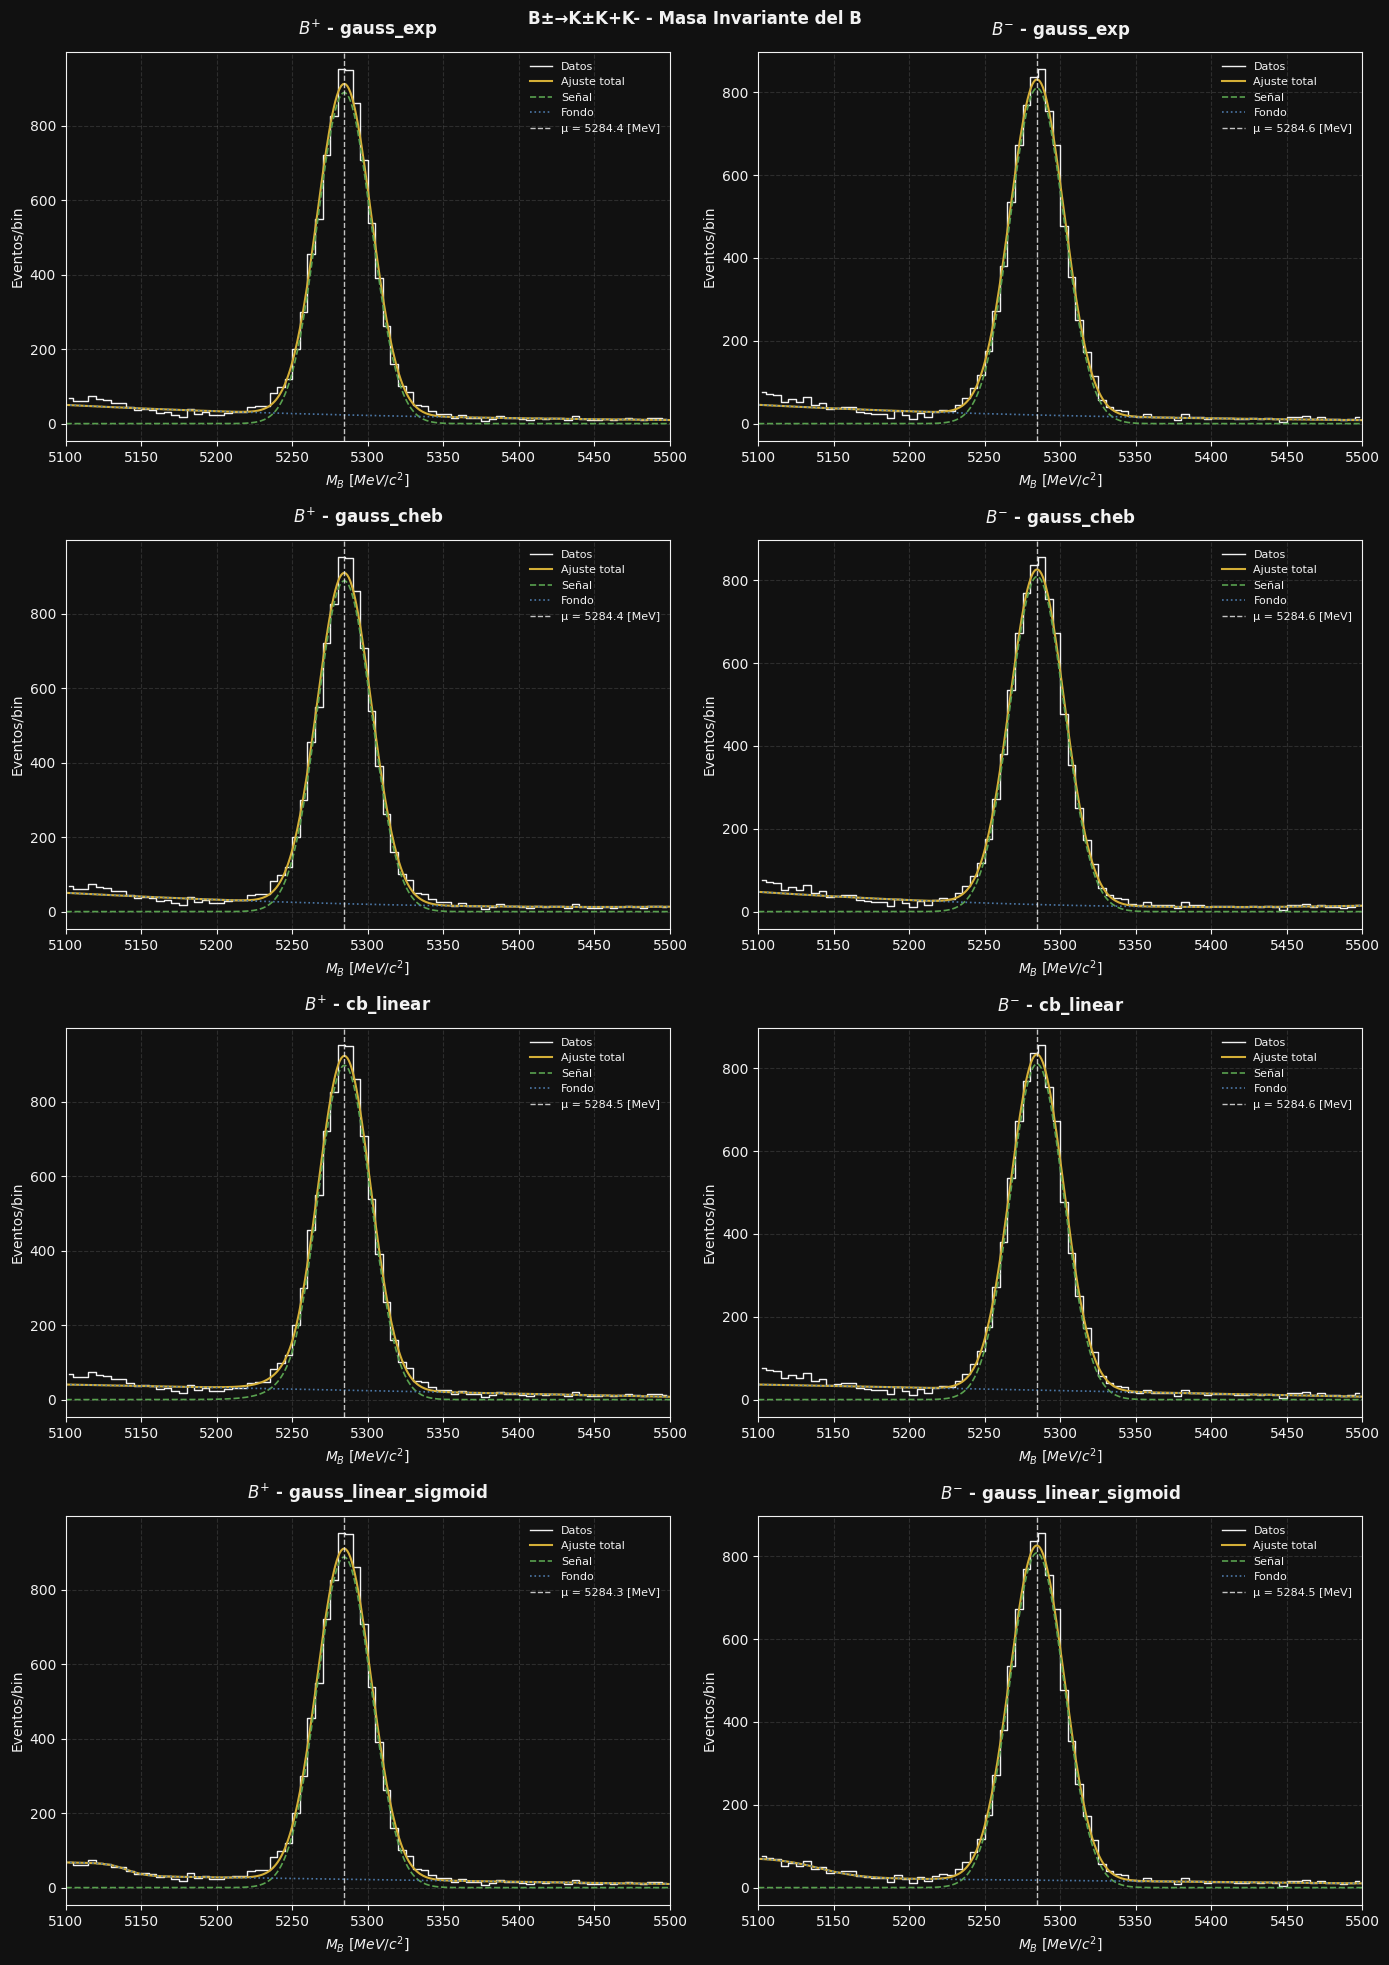

In [24]:
fit_results_KKK = pl.plot_mass_by_charge(
    df_KKK,
    cn_KKK,
    fit_model=models,
    save=True,
    data='data',
)